In [1]:
#import libraries 

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import sqlite3 

# 1 Import data / database 

In [2]:
# Import Dataset
df = pd.read_csv("data/simulated/customer_churn_5000.csv")

In [3]:
date_cols = [
    "dob",
    "subscription_start_date",
    "renewal_date",
    "cancellation_date"
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col])

In [4]:
df.dtypes

customerid                          int64
customer_name                      object
gender                             object
country                            object
state                              object
dob                        datetime64[ns]
subscription_start_date    datetime64[ns]
subscription_type                  object
renewal_date               datetime64[ns]
plan_type                          object
contract_type                      object
cancellation_date          datetime64[ns]
cancellation_reason                object
monthly_charges                     int64
cltv                              float64
churn_score                         int64
churn_flag                          int64
escalations                         int64
csat_score                          int64
complaint_count                     int64
dtype: object

# 4 Data Analysis

In [5]:
# 1 Churn Rate 

churn_rate = df["churn_flag"].mean()*100
print("Churn Rate = " , round(churn_rate,2),"%")

Churn Rate =  20.08 %


In [6]:
# 2 Retention Rate 

retention_rate = 100 - churn_rate
print("Retention Rate = " , round(retention_rate,2),"%")

Retention Rate =  79.92 %


In [7]:
df.head(3)

,customerid,customer_name,gender,country,state,dob,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag,escalations,csat_score,complaint_count
0,100001,Aryan Maharaj,Male,India,Delhi,1996-05-04,2024-11-22 01:37:15,Premium,2025-02-09 01:37:15,Premium,Monthly,NaT,Active,1471,24859.9,35,0,0,5,0
1,100002,Udant Dewan,Female,India,Delhi,1967-05-14,2022-06-18 22:15:15,Regular,2022-10-22 22:15:15,Standard,Monthly,NaT,Active,687,22671.0,42,0,0,5,1
2,100003,Gagan Sami,Female,India,Uttar Pradesh,2005-10-01,2024-01-02 00:34:28,Regular,2024-10-09 00:34:28,Standard,Monthly,2024-06-21 00:34:28,Poor Service,823,11522.0,95,1,3,1,2


In [8]:
# 3 Churn by Plan type

churn_by_plan = (df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name = 'churn_rate_cpt'))
print(churn_by_plan)

  plan_type  churn_rate_cpt
0     Basic           21.64
1   Premium           13.93
2  Standard           21.64


In [9]:
#4 a. Churn rate by state + sum of revenue & count of users 

churn_by_state = (
    df.groupby("state")
      .agg(
          churn_rate_pct=("churn_flag", lambda x: x.mean() * 100),
          total_revenue=("monthly_charges", "sum"),
          user_count=("customerid", "count")
      )
      .round({"churn_rate_pct": 2, "total_revenue": 2})
      .reset_index()
)

print(churn_by_state)


           state  churn_rate_pct  total_revenue  user_count
0          Delhi           19.50         434681         636
1        Gujarat           19.84         425786         640
2      Karnataka           19.84         509664         766
3    Maharashtra           18.80         728794        1117
4      Rajasthan           20.32         290800         438
5     Tamil Nadu           23.94         309585         472
6      Telangana           20.73         302459         463
7  Uttar Pradesh           19.87         317961         468


In [10]:
# b. Churn rate by ssubscription + sum of revenue & count of users 

churn_by_subscription = df.groupby('subscription_type').agg(
    churn_rate_cpt=('churn_flag', lambda x: round(x.mean() * 100, 2)),
    total_revenue=('monthly_charges', 'sum'),
    user_count=('customerid', 'count')
).reset_index()

print(churn_by_subscription)

  subscription_type  churn_rate_cpt  total_revenue  user_count
0           Premium           13.93        1211640        1012
1           Regular           21.64        2108090        3988


In [11]:
# 5 ARPU - Avg Revenue per User 

arpu = df['monthly_charges'].mean()
print("ARPU = ", round(arpu,2))

ARPU =  663.95


In [12]:
# 6 Avg Customer tenure 
# count of days user has used our service : cancellation date else current date 

today = pd.Timestamp("2025-12-31")

df['tenure_days'] = np.where(
    df['cancellation_date'].notna(),
    (df['cancellation_date'] - df['subscription_start_date']).dt.days,
     (today - df['subscription_start_date'] ).dt.days
)

avg_tenure = df['tenure_days'].mean()
print("Avg Tenure (days) = ", round(avg_tenure),0)

Avg Tenure (days) =  771 0


In [13]:
# 7 Revenue at risk - revenue lost from churned users 

revenue_at_risk = df.loc[df['churn_flag'] == 1, 'monthly_charges'].sum()
print("Revenue at risk  = " , revenue_at_risk,"k")

Revenue at risk  =  624592 k


In [14]:
# 8 Esclation Rate

escalation_rate = (df['escalations'] =='Y').mean()*100
print("Escalation Rate = " , round(escalation_rate,2),"%")


Escalation Rate =  0.0 %


In [15]:
# 9 Avg Complaint Per User 

avg_complaints = df['complaint_count'].sum() / df['customerid'].nunique()
print("Avg Complaints Per User = ", round(avg_complaints, 2))

Avg Complaints Per User =  1.32


In [16]:
# 10 Correlation Escalation VS Churn

df['escalations'] = np.where(df['escalations'] == 'Y' ,1,0) # encoding string to int type


corr_df = df[['customerid' , 'escalations' , 'churn_flag']].dropna()

# correlations

correlation = corr_df['escalations'].corr(df['churn_flag'])
print("Correlation between escaltion vs churn is =" , round(correlation,2))

Correlation between escaltion vs churn is = nan


C:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [17]:
# 11 churn risk - create a column using existing col 

conditions = [
    (df['churn_score']<50),
    (df['churn_score']>=50) & (df['churn_score'] < 70),
    (df['churn_score'] >= 70 )
]

choices = ['low ' , 'med' , 'high']

df['churn_risk'] = np.select(conditions , choices , default ='unknown')

## 4 Visualizations using matplotlib

In [18]:
df_visual = df.copy()

In [19]:
df_visual.columns

Index(['customerid', 'customer_name', 'gender', 'country', 'state', 'dob',
       'subscription_start_date', 'subscription_type', 'renewal_date',
       'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk'],
      dtype='object')

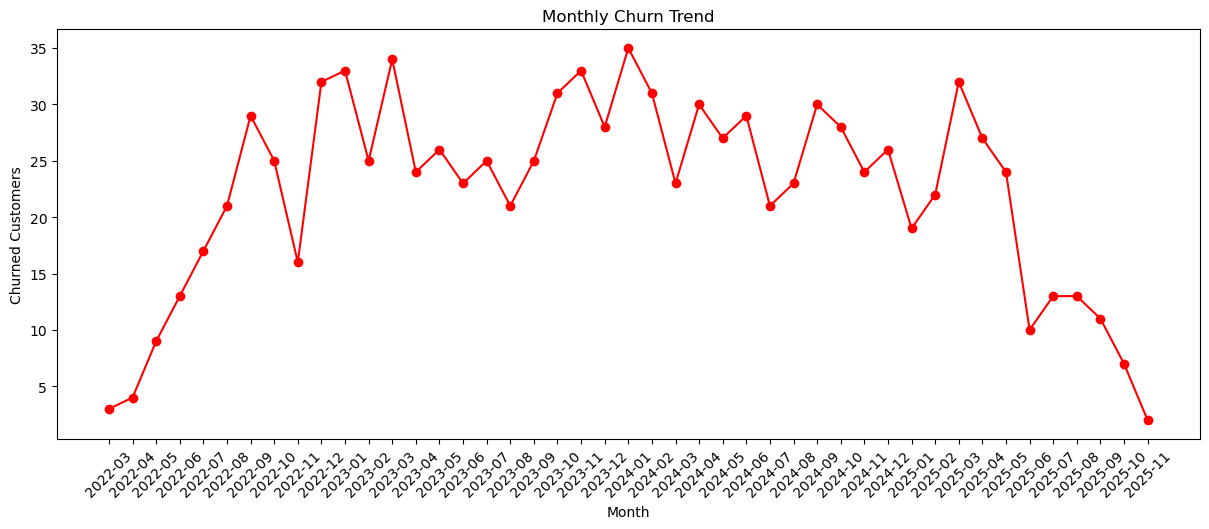

In [20]:
df_visual["cancellation_month"] = df_visual["cancellation_date"].dt.to_period("M")

churn_trend = (
    df_visual[df_visual["churn_flag"] == 1]
    .groupby("cancellation_month")
    .size()
)

plt.figure(figsize=(12,5))

plt.plot(
    churn_trend.index.astype(str),
    churn_trend.values,
    marker="o",
    color="red"
)

plt.xticks(rotation=45)
plt.tight_layout()

plt.title("Monthly Churn Trend")
plt.xlabel("Month")
plt.ylabel("Churned Customers")

plt.show()

<BarContainer object of 3 artists>

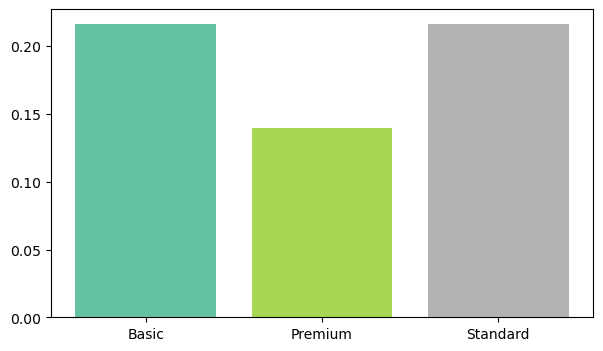

In [21]:
# 4.2 Churn by plan type 

churn_plan = df_visual.groupby('plan_type')['churn_flag'].mean()
colors = plt.cm.Set2(np.linspace(0,1 , len(churn_plan)))
plt.figure(figsize =(7,4))

plt.bar(churn_plan.index , churn_plan.values, color = colors )

<BarContainer object of 8 artists>

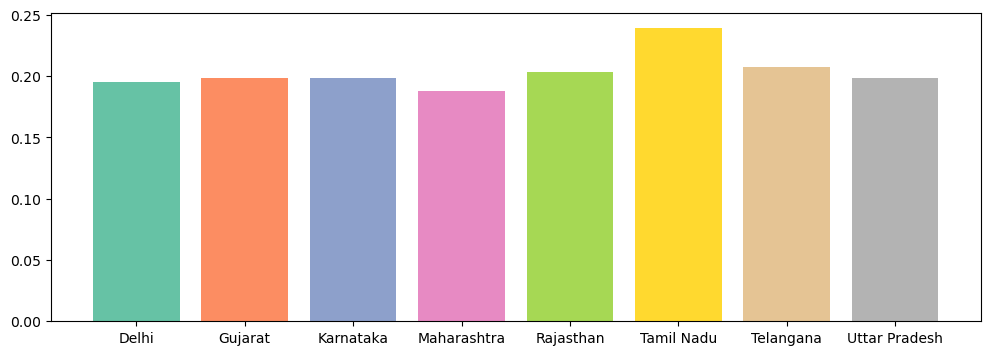

In [22]:
# 4.3 Churn by state

churn_plan = df_visual.groupby('state')['churn_flag'].mean()
colors = plt.cm.Set2(np.linspace(0,1 , len(churn_plan)))
plt.figure(figsize =(12,4))

plt.bar(churn_plan.index , churn_plan.values, color = colors )

# 5 Visualizations Using Seaborn 

In [23]:
# encoding - convert str to numeric values
df_visual.columns

Index(['customerid', 'customer_name', 'gender', 'country', 'state', 'dob',
       'subscription_start_date', 'subscription_type', 'renewal_date',
       'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='object')

In [24]:
import warnings 
warnings.filterwarnings('ignore')

In [25]:
# moethod of encoding - based on priority 

df_encoded = df_visual[['plan_type', 'contract_type', 'churn_score','churn_flag', 'escalations', 'churn_risk']]

order_mappings = {'plan_type' : ['Basic', 'Standard' ,'Premium'],
                  
                  'contract_type' : ['Monthly' , 'Annual'],
                  
                  'churn_risk' : ['low' , 'med' , 'high']}

for col,order in order_mappings.items():
    df_encoded[col] = pd.Categorical(df_encoded[col].astype('category'), categories=order , ordered=True).codes

In [26]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,escalations,churn_risk
0,2,0,35,0,0,-1
1,1,0,42,0,0,-1
2,1,0,95,1,0,2
3,1,0,37,0,0,-1
4,1,1,23,0,0,-1


In [27]:
df_visual[['plan_type', 'contract_type', 'churn_score','churn_flag', 'escalations', 'churn_risk']].head()

,plan_type,contract_type,churn_score,churn_flag,escalations,churn_risk
0,Premium,Monthly,35,0,0,low
1,Standard,Monthly,42,0,0,low
2,Standard,Monthly,95,1,0,high
3,Standard,Monthly,37,0,0,low
4,Standard,Annual,23,0,0,low


<Axes: >

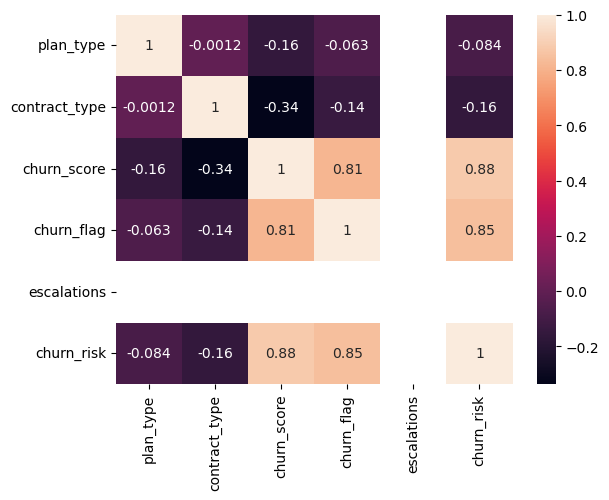

In [28]:
# heatmap (correlation matrix ) 

sns.heatmap(df_encoded.corr(), annot=True)

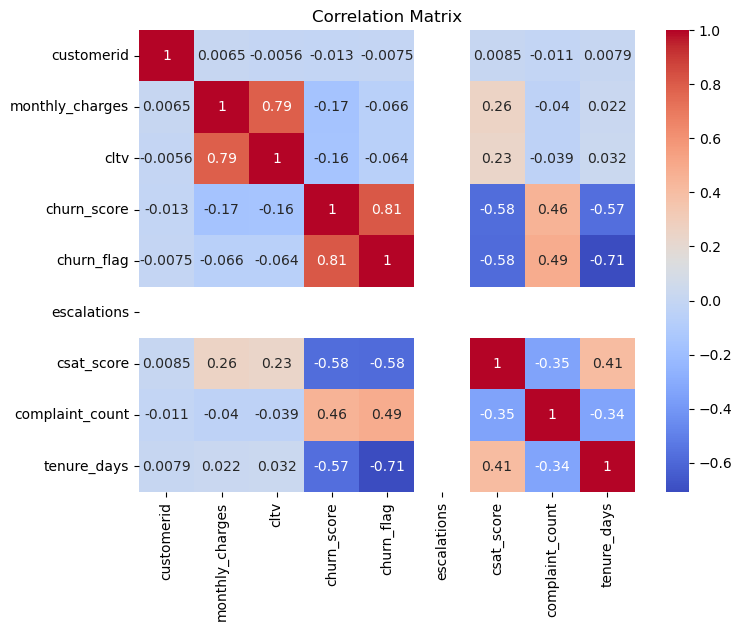

In [29]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df_visual.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

<Axes: xlabel='plan_type', ylabel='monthly_charges'>

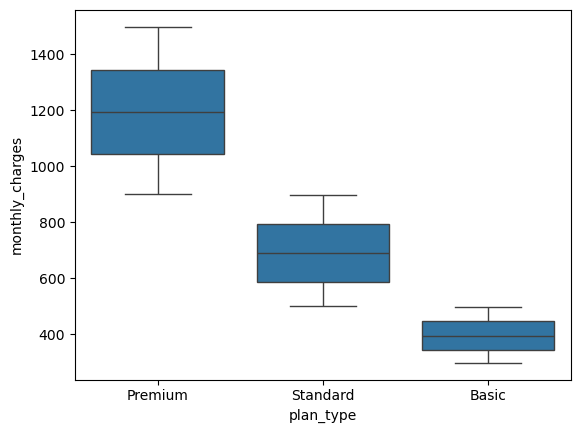

In [30]:
sns.boxplot(
    data=df_visual,
    x="plan_type",
    y="monthly_charges"
)

In [31]:
# pivot tables 

pd.pivot_table(
    df_visual,
    values= 'churn_flag',
    index='plan_type',
    aggfunc ='mean'
              
              ).reset_index()

,plan_type,churn_flag
0,Basic,0.216388
1,Premium,0.139328
2,Standard,0.216414


In [32]:
pd.pivot_table(
    df_visual,
    values= ['churn_flag', 'monthly_charges', 'customerid'],
    index='plan_type',
    aggfunc = {
        'churn_flag': 'mean' ,
        'monthly_charges': 'sum',
        'customerid': 'nunique'
    }
              
              )

,churn_flag,customerid,monthly_charges
plan_type,,,
Basic,0.216388,2209,876199
Premium,0.139328,1012,1211640
Standard,0.216414,1779,1231891


In [33]:
# working with SQL in python (pandas)

In [34]:
# create database in sql 


conn = sqlite3.connect('test_database.sqlite')

# table details

conn.execute("CREATE TABLE users(first_name TEXT , country TEXT , budget INTEGER)")

OperationalError: table users already exists

In [ ]:
# Commit and save 

conn.commit()

In [ ]:
# insert data 
cursor = conn.cursor() 

cursor.execute("""
    INSERT INTO users VALUES 
    ('Utkarsh', 'india', 5000), 
    ('rishab', 'usa', 6000) 
""") 

conn.commit() 
print("data inserted successfully")

In [ ]:
# check inserted data in table 

conn = sqlite3.connect('test_database.sqlite')
query = """ SELECT * FROM users """

df_results = pd.read_sql(query , conn)

df_results

In [ ]:
df.to_csv(
    "data/synthetic/customer_churn_5000.csv",
    index=False
)

In [35]:
import os

print(os.getcwd())

C:\Users\USER\PROJECT\Churn Analysis\data
